# 3.1.2 内积范数与投影

## 学习目标与先修知识

能计算内积（inner product）、欧几里得范数（Euclidean norm）与投影（projection），把两室变化分成共同方向和差异方向，并解释单位与尺度对几何比较的影响。

先修：上一节的二维向量（vector）、矩阵乘法（matrix multiplication）与单位。 [复习上一节](01-两室交换与矩阵收支.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两室相对某个参考分布的偏差是 [3,1] U。它有多少沿“两个室一起改变”的方向，又有多少只是在两室间重新分配？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
x=np.array([3.,1.]);shared=np.array([2.,2.]);redistributed=np.array([1.,-1.])
display(Markdown(show_table(['部分','室 1 / U','室 2 / U','分量和 / U'],[(name,*v,sum(v)) for name,v in [('原偏差',x),('共同变化',shared),('重新分配',redistributed)]])))

| 部分 | 室 1 / U | 室 2 / U | 分量和 / U |
| --- | --- | --- | --- |
| 原偏差 | 3 | 1 | 4 |
| 共同变化 | 2 | 2 | 4 |
| 重新分配 | 1 | -1 | 0 |

## 模型假设

两个坐标都以 U 表示偏离量；负值表示低于各自的参考水平。采用普通欧几里得几何，两个坐标的一个 U 使用相同绘图长度。共同方向 d=[1,1]，方向向量可任意缩放，零向量不能指定方向。

## 数学解释与推导

内积 $x\cdot d=\sum_i x_i d_i$ 把对应分量相乘再求和。范数（norm） $\|x\|_2=\sqrt{x\cdot x}$ 是长度；下标 2 指平方和形式。二维勾股定理说明它对应直角坐标中的距离。若 $x\cdot d=0$，二者正交（orthogonality），即互相垂直。

投影要寻找沿 d 的向量 $p=\alpha d$，使余量 $r=x-p$ 与 d 垂直。令 $(x-\alpha d)\cdot d=0$，得到
$$\alpha=\frac{x\cdot d}{d\cdot d},\qquad p=\frac{x\cdot d}{d\cdot d}d,\qquad r=x-p.$$
本例 $x\cdot d=4$、$d\cdot d=2$，故 p=[2,2]、r=[1,−1]。还可从“最近”理解：将 $\|x-\alpha d\|^2$ 展开为 $x\cdot x-2\alpha x\cdot d+\alpha^2d\cdot d$，配方可见上述 α 是唯一最小点。这是以后最小二乘的几何起点。

共同方向 [1,1] 与差异方向 [1,−1] 正交，任意二维向量都能写成两者之和，系数分别是 $(x_1+x_2)/2$ 和 $(x_1-x_2)/2$。它们是基（basis）：两个独立方向可以表达平面中的任意向量。一组向量线性无关（linearly independent），是指只有系数全零时它们的线性组合才为零；二维情况下，这两个方向不平行，便不会重复同一条方向信息。这里的系数描述共同方向和差异方向上的分量。

内积单位为 U²，范数单位为 U，系数 α 在 x 与 d 同单位时无量纲（dimensionless）。范数一般不是守恒量，例如 [6,0] 与 [3,3] 的总量相同，长度却不同。若把总量与温度组合，必须先说明尺度，如 $(A/A_{\rm ref},\theta/\theta_{\rm ref})$；选择不同参考尺度会改变距离，不能默认有唯一自然的“系统长度”。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def projection(vector, direction):
    import math
    dot = sum(x*y for x, y in zip(vector, direction))
    length = math.sqrt(sum(x*x for x in vector))
    scale = dot / sum(y*y for y in direction)
    projected = [scale*y for y in direction]
    residual = [x-y for x, y in zip(vector, projected)]
    return dot, length, projected, residual

## 对照实验

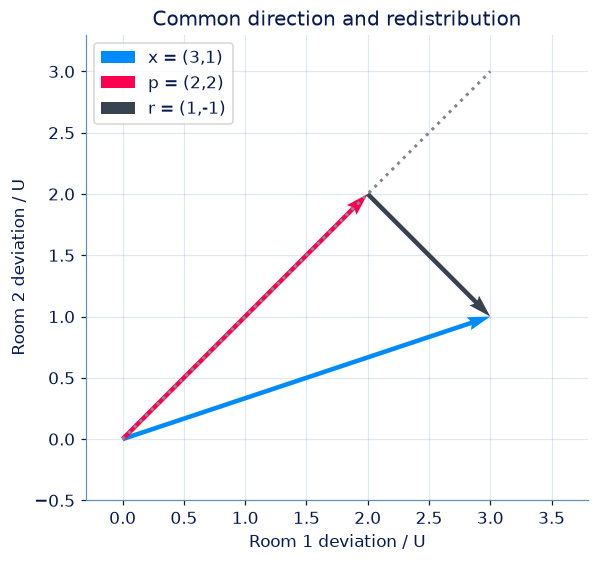

| 内积 / U² | 长度 / U | 余量与方向内积 / U² |
| --- | --- | --- |
| 4 | 3.16228 | 0 |

In [4]:
dot,length,p,r=projection([3,1],[1,1])
fig,ax=plt.subplots(figsize=(6,5))
for vector,color,label,start in [(x,BLUE,'x = (3,1)',[0,0]),(p,PINK,'p = (2,2)',[0,0]),(r,'#384251','r = (1,-1)',p)]:
    ax.quiver(*start,*vector,angles='xy',scale_units='xy',scale=1,color=color,width=.009,label=label)
ax.plot([0,3],[0,3],':',color='#888888');ax.set(xlim=(-.3,3.8),ylim=(-.5,3.3),xlabel='Room 1 deviation / U',ylabel='Room 2 deviation / U',title='Common direction and redistribution')
ax.set_aspect('equal');ax.legend(loc='upper left');plt.show()
display(Markdown(show_table(['内积 / U²','长度 / U','余量与方向内积 / U²'],[(dot,length,np.dot(r,[1,1]))])))

## 结果解释

蓝箭头是原偏差，玫红箭头沿共同方向，灰箭头从投影端点接到原偏差端点。等比例坐标使垂直关系可见；数值内积为零才是核对依据。

### 独立核对

分解重建只是第一步；余量正交、勾股关系以及方向缩放不变性提供额外检查。

In [5]:
for x,d in [([3,1],[1,1]),([2,-2],[1,1]),([0,0],[1,0]),([-1,3],[0,2])]:
    dot,length,p,r=projection(x,d)
    np.testing.assert_allclose(np.array(p)+r,x)
    assert abs(np.dot(r,d))<1e-12
    assert math.isclose(length**2,np.dot(p,p)+np.dot(r,r),abs_tol=1e-12)
    np.testing.assert_allclose(projection(x,[2*z for z in d])[2],p)
print('正交余量、勾股分解和方向缩放不变性均通过。')

正交余量、勾股分解和方向缩放不变性均通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：沿指定方向分解变化

给定两个以相同单位 U 表示的二维向量（vector）。把 vector 分解为沿非零 direction 的投影（projection）和垂直余量，同时返回内积（inner product）与原向量的欧几里得范数（Euclidean norm）。

**函数与代码模板**

```python
def solve(
    vector: list[float],
    direction: list[float],
) -> tuple[float, float, list[float], list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `vector` | `list[float]` | 待分解的二维向量。 | U |
| `direction` | `list[float]` | 指定方向，保证不是零向量。 | U |

**返回值**

按以下顺序返回元组：(dot, length, projected, residual)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `dot` | `float` | vector 与 direction 的内积。 | U² |
| `length` | `float` | vector 的欧几里得范数。 | U |
| `projected` | `list[float]` | 沿 direction 的投影向量。 | U |
| `residual` | `list[float]` | vector 减 projected。 | U |

**计算规则**

dot=Σ vector[i]direction[i]；length=sqrt(Σ vector[i]²)；projected=direction×dot/Σ direction[i]²；residual=vector−projected。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 两个列表长度为 2；各分量绝对值≤20；direction 的平方和≥0.01。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| vector | 待分解的二维向量。 | [3, 1] | U |
| direction | 指定方向，保证不是零向量。 | [1, 1] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
vector = [3, 1]
direction = [1, 1]

result = solve(vector, direction)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| dot | vector 与 direction 的内积。 | 4 | U² |
| length | vector 的欧几里得范数。 | ≈ 3.162278 | U |
| projected | 沿 direction 的投影向量。 | [2.0, 2.0] | U |
| residual | vector 减 projected。 | [1.0, -1.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (4,
                   3.1622776601683795,
                   [2.0, 2.0],
                   [1.0, -1.0])
```

**样例解释**

内积为 4，范数（norm）为 sqrt(10)；投影为 [2,2]，余量为 [1,−1]，余量与 [1,1] 内积为零。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：沿指定方向分解变化](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-projection)

### 第 2 题 · 单项选择题：长度依赖怎样的坐标

状态（state）由所追踪物质总量（tracked amount） A /U 和温度 θ /℃ 组成。直接计算 sqrt(A²+θ²) 并称为系统总量，哪里有问题？

- **A.** 不同单位直接相加缺乏所需的度量定义，应先明确各自尺度与比较目的。
- **B.** 只要放入 NumPy 数组（array）就有统一物理单位。
- **C.** 平方会自动消除单位。
- **D.** 任何范数（norm）都等于守恒总量。

[作答：长度依赖怎样的坐标](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-norm-units)

### 第 3 题 · 多项选择题：投影误差为什么垂直

对同单位向量（vector） x，用 p=αd 逼近 x，d≠0。选择 α=(x·d)/(d·d)。哪些成立？

- **A.** (x−p)·d=0。
- **B.** 任何 x 都等于 p。
- **C.** 这个 α 使 ||x−αd||² 最小。
- **D.** d 放大两倍后，投影（projection）向量 p 保持不变。

[作答：投影误差为什么垂直](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-projection-meaning)

### 第 4 题 · 单项选择题：矩阵乘法怎样读取

M=[[-0.2,0.1],[0.2,−0.1]]，x=[6,0]。为什么 M@x 等于 [−1.2,1.2] 而非逐元素结果？

- **A.** 每个结果分量是矩阵（matrix）一行与向量（vector）的内积（inner product）。
- **B.** @ 自动寻找平衡（equilibrium）。
- **C.** @ 与 * 对任意 NumPy 数组（array）都等价。
- **D.** 结果分量由对应行元素相乘得到。

[作答：矩阵乘法怎样读取](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-matrix-product)

**进一步阅读**

[Boyd 与 Vandenberghe：应用线性代数](https://web.stanford.edu/~boyd/vmls/)：向量、范数、独立性与线性方程。